In [ ]:
from google.colab import files
files.upload()

Saving Perceptron.xlsx to Perceptron (1).xlsx


{'Perceptron (1).xlsx': b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00LA\x02\x11_\x01\x00\x00\x90\x04\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
def save_plot(filename):
    """Save a matplotlib figure as a 600 DPI .eps file and trigger a Colab download."""
    path = f"{filename}.eps"
    plt.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")

note to self:

image format: .eps
600 dpi

x axis, y axis, label, legend in TNR bold font size 15

In [ ]:
#Task 1: Dataset EXploration

import pandas as pd

df=pd.read_excel("Perceptron.xlsx")


print(df.head())
print()
print("Dimensions: ", df.shape)
print()
print("Missing values per column:")
df.isnull().sum()



   Variance  Skewness  Curtosis  Entropy  Target Class
0   3.62160    8.6661   -2.8073 -0.44699             0
1   4.54590    8.1674   -2.4586 -1.46210             0
2   3.86600   -2.6383    1.9242  0.10645             0
3   3.45660    9.5228   -4.0112 -3.59440             0
4   0.32924   -4.4552    4.5718 -0.98880             0

Dimensions:  (1372, 5)

Missing values per column:


,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Target Class,0


In [ ]:
print("General statistics: ")
df.describe()

General statistics: 


,Variance,Skewness,Curtosis,Entropy,Target Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
#Task 2: EDA

import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ['Variance', 'Skewness', 'Curtosis', 'Entropy']
target_col = 'Target Class'

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: feature_histograms.eps


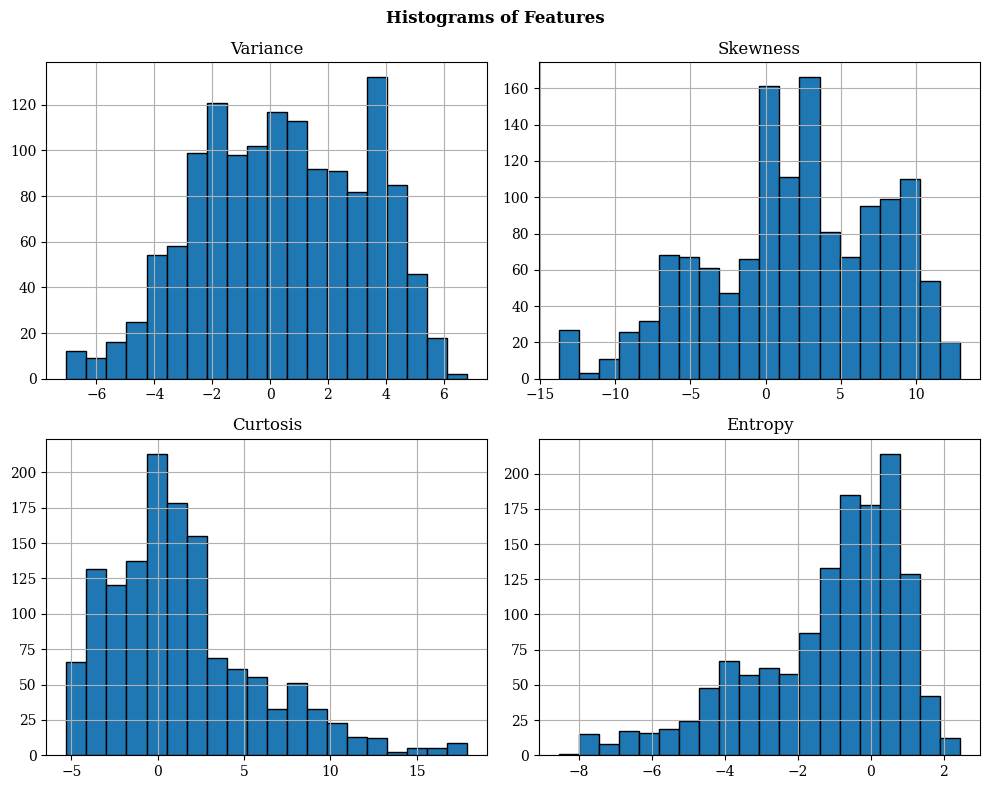

In [ ]:
#Histogram
df[feature_cols].hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle("Histograms of Features", fontweight="bold")
plt.tight_layout()
save_plot("feature_histograms")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: corr_heatmap.eps


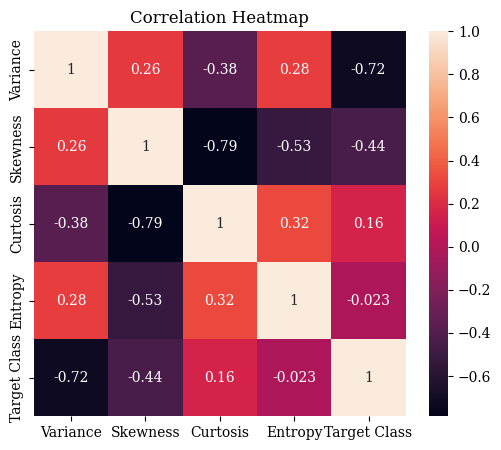

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
save_plot("corr_heatmap")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: scatter_plot.eps


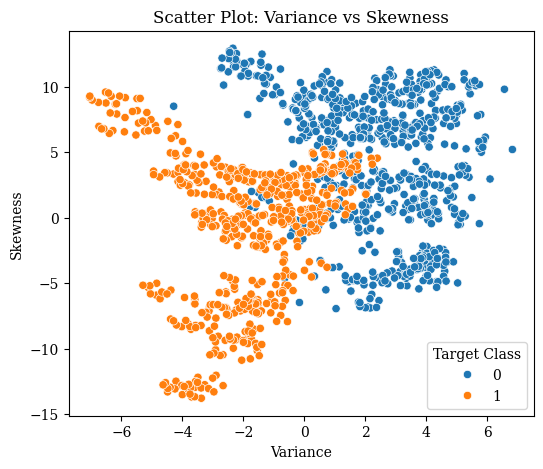

In [ ]:
#Scatter plot for variance vs skewness
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='Variance', y='Skewness', hue=target_col)
plt.title("Scatter Plot: Variance vs Skewness")
save_plot("scatter_plot")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: feature_boxplot.eps


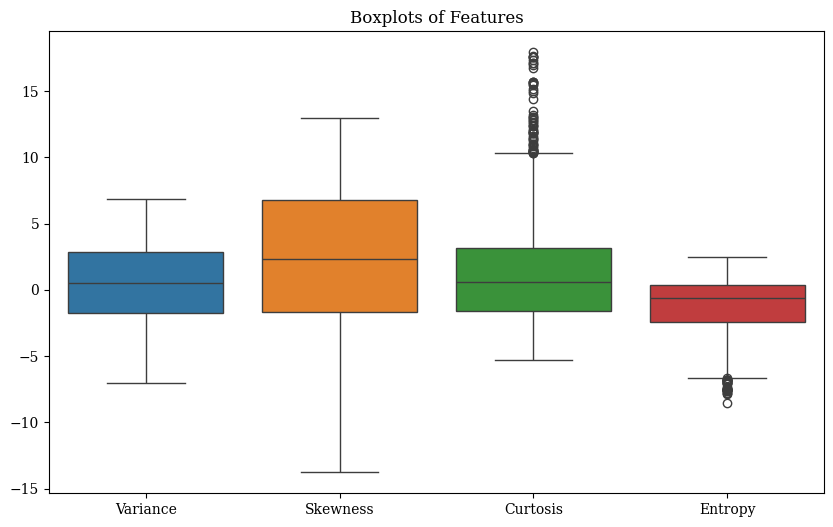

In [ ]:
#Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[feature_cols])
plt.title("Boxplots of Features")
save_plot("feature_boxplot")
plt.show()

In [ ]:
#Task 3: Data preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x=df[feature_cols]
y=df[target_col]

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled_df=pd.DataFrame(x_scaled, columns=feature_cols)

#Train test split
x_train, x_test, y_train, y_test=train_test_split(x_scaled_df, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(1097, 4)
(275, 4)


In [ ]:
#Task 4: Perceptron implementation

import numpy as np

class Perceptron:
    def __init__(self, n_features, learning_rate=0.01):
        #Weight initialization
        self.weights = np.zeros(n_features)

        # Bias Initialization
        self.bias = 0.0

        self.lr = learning_rate

    #Step activation
    def step_function(self, z):
        return np.where(z >= 0, 1, 0)

    #Forward propagation
    def forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_function(z)

    #Perceptron Learning Rule
    def update_weights(self, x_i, y_true, y_pred):
        error = y_true - y_pred
        self.weights += self.lr * error * x_i
        self.bias += self.lr * error
        return error

In [ ]:
#Task 5: Model training

import numpy as np

# Convert to numpy arrays (in case they are still DataFrames/Series)
X_train_np = x_train.to_numpy() if hasattr(x_train, "to_numpy") else x_train
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train

X_test_np = x_test.to_numpy() if hasattr(x_test, "to_numpy") else x_test
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test

n_features = X_train_np.shape[1]
n_epochs = 20

# Initialize perceptron
model = Perceptron(n_features=n_features, learning_rate=0.01)

# ---- Storage for later plotting in Task 7 ----
error_history = []
weight_history = []
bias_history = []

print("Initial Weights:", model.weights)
print("Initial Bias:", model.bias)
print("-" * 60)

for epoch in range(1, n_epochs + 1):
    misclassified_count = 0

    for x_i, y_true in zip(X_train_np, y_train_np):
        y_pred = model.forward(x_i.reshape(1, -1))[0]

        if y_pred != y_true:
            misclassified_count += 1
            model.update_weights(x_i, y_true, y_pred)

    # ---- Store history for Task 7 plots ----
    error_history.append(misclassified_count)
    weight_history.append(model.weights.copy())
    bias_history.append(model.bias)

    # ---- Display epoch details ----
    print(f"Epoch {epoch}")
    print(f"  Misclassified Samples : {misclassified_count}")
    print(f"  Updated Weights       : {model.weights}")
    print(f"  Updated Bias          : {model.bias}")
    print("-" * 60)

    # Stop early if perfectly classified
    if misclassified_count == 0:
        print(f"Converged at epoch {epoch}. Stopping training.")
        break

weight_history = np.array(weight_history)   # shape: (epochs_run, n_features)
bias_history = np.array(bias_history)

Initial Weights: [0. 0. 0. 0.]
Initial Bias: 0.0
------------------------------------------------------------
Epoch 1
  Misclassified Samples : 47
  Updated Weights       : [-0.07253688 -0.06486266 -0.06445982  0.00019858]
  Updated Bias          : -0.03
------------------------------------------------------------
Epoch 2
  Misclassified Samples : 26
  Updated Weights       : [-0.08217015 -0.09380199 -0.05149354 -0.00518242]
  Updated Bias          : -0.03
------------------------------------------------------------
Epoch 3
  Misclassified Samples : 34
  Updated Weights       : [-0.09467641 -0.09140031 -0.08905542 -0.00956468]
  Updated Bias          : -0.05
------------------------------------------------------------
Epoch 4
  Misclassified Samples : 23
  Updated Weights       : [-0.11074483 -0.09580878 -0.10630688 -0.01312422]
  Updated Bias          : -0.04
------------------------------------------------------------
Epoch 5
  Misclassified Samples : 27
  Updated Weights       : [-0

In [ ]:
#Task 6: Model evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions on test set
y_pred_test = model.forward(X_test_np)


# ---- Optional cross-check with scikit-learn
print("Accuracy :", accuracy_score(y_test_np, y_pred_test))
print("Precision:", precision_score(y_test_np, y_pred_test))
print("Recall :", recall_score(y_test_np, y_pred_test))
print("F1 score :", f1_score(y_test_np, y_pred_test))

Accuracy : 0.9636363636363636
Precision: 1.0
Recall : 0.9212598425196851
F1 score : 0.9590163934426229


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: conf_matrix.eps


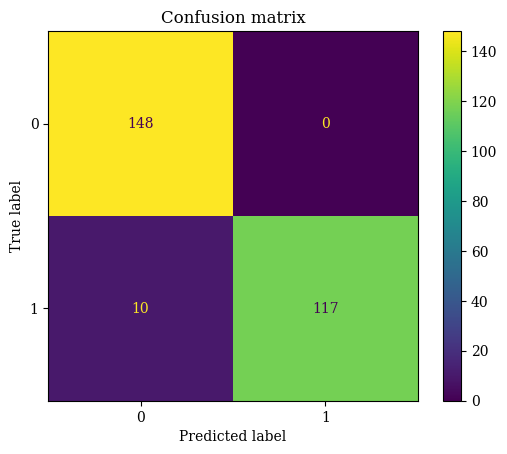

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_np, y_pred_test))
disp.plot()
plt.title("Confusion matrix")
save_plot("conf_matrix")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: train_error_vs_epoch.eps


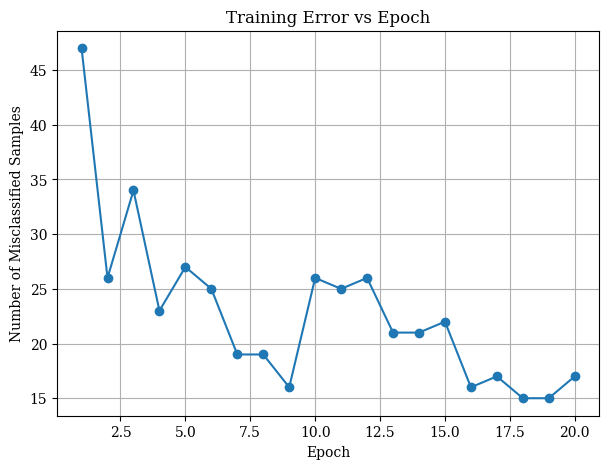

In [ ]:
#Task 7: Important Plots

# 4. Training Error vs Epoch
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(error_history) + 1), error_history, marker='o')
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.grid(True)
save_plot("train_error_vs_epoch")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: weight_evol.eps


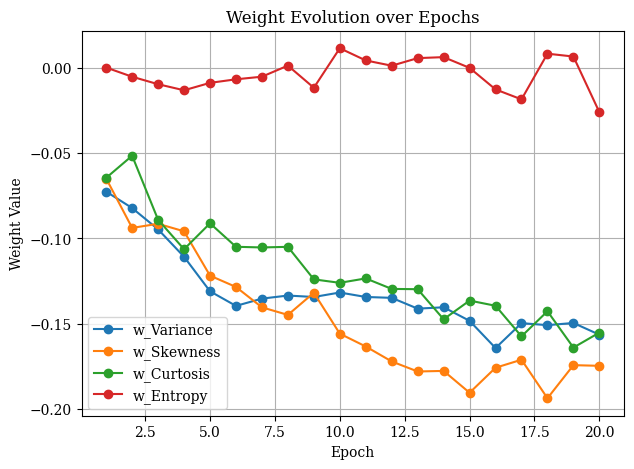

In [ ]:
plt.figure(figsize=(7, 5))
for i, col in enumerate(feature_cols):
    plt.plot(range(1, len(weight_history) + 1), weight_history[:, i], marker='o', label=f'w_{col}')
plt.title("Weight Evolution over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
save_plot("weight_evol")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: bias_evol.eps


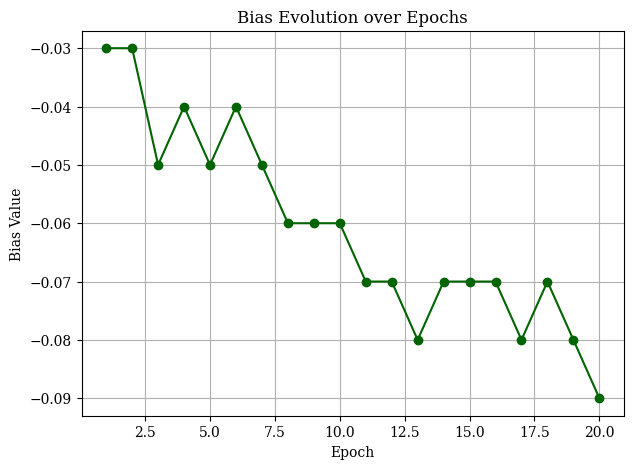

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(bias_history) + 1), bias_history, marker='o', color='darkgreen')
plt.title("Bias Evolution over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(True)
save_plot("bias_evol")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: lr_comparison.eps


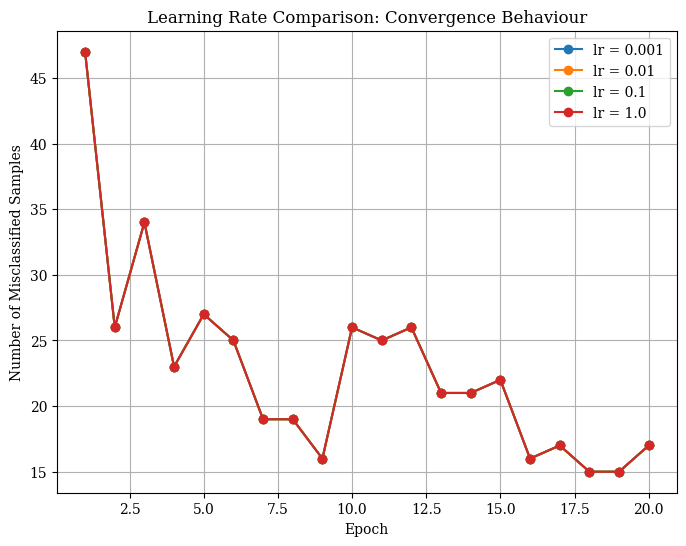

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
lr_error_histories = {}

for lr in learning_rates:
    temp_model = Perceptron(n_features=n_features, learning_rate=lr)
    temp_error_history = []

    for epoch in range(n_epochs):
        misclassified_count = 0
        for x_i, y_true in zip(X_train_np, y_train_np):
            y_pred = temp_model.forward(x_i.reshape(1, -1))[0]
            if y_pred != y_true:
                misclassified_count += 1
                temp_model.update_weights(x_i, y_true, y_pred)
        temp_error_history.append(misclassified_count)

    lr_error_histories[lr] = temp_error_history

plt.figure(figsize=(8, 6))
for lr, errors in lr_error_histories.items():
    plt.plot(range(1, len(errors) + 1), errors, marker='o', label=f'lr = {lr}')
plt.title("Learning Rate Comparison: Convergence Behaviour")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.legend()
plt.grid(True)
save_plot("lr_comparison")
plt.show()